# RNN simples com a diferença


- 1 saida - DeltaTheta
- 2 entradas - Pwmd, Pwme 
- 1 camada
- 1 neurônio


In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

Datasets = []
PREDICTORS = ["PwmD", "PwmE", "Theta"]
TARGET = "Y"       

for i in range(3):   
    Dataset = pd.read_csv(f"../../Dados/Data{i + 1}.csv")
        
    # Ajusta índice pelo tempo
    Dataset.index = (np.arange(0, len(Dataset), 1).astype(float) * 0.07).round(5)    
    Datasets.append(Dataset)

    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Dataset.head(5))


++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
        X    Y  Theta    Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7   0.00  0.00  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7   0.00  0.00  0.0   3.02   3.02  -0.00   0.00
0.14  0.0  0.7   0.00  0.00  0.0   3.02   3.02  45.32  45.32
0.21  0.0  0.7   0.01  0.36  0.0   3.02   3.02  45.32  45.32
0.28  0.0  0.7   0.01  0.20  0.0   2.99   3.02  57.60  63.38
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
        X    Y  Theta    Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.00  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7    0.0  0.00  0.0   3.02   3.02  -0.00   0.00
0.14  0.0  0.7    0.0  0.00  0.0   3.02   3.02  45.32  45.32
0.21  0.0  0.7    0.0  0.03  0.0   3.02   3.02  45.32  45.32
0.28  0.0  0.7    0.0  0.00  0.0   3.02   3.02  63.00  63.44
++++++++++++++++++++ Dataset 3 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.

In [15]:
for  i in range(3):
    Dataset = Datasets[i].copy()
    Dataset["DeltaY"] = Dataset[TARGET].shift(-1) - Dataset[TARGET]
    
    Dataset = Dataset.dropna(subset=["DeltaY"])
    Datasets[i] = Dataset
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Datasets[i].tail(5))


++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
          X     Y  Theta    Wd    We  WdRef  WeRef    PwmD    PwmE  DeltaY
99.05  0.05  0.65  -0.83 -2.76 -3.35  -2.84  -3.05 -103.15 -117.71    0.00
99.12  0.05  0.65  -0.83 -2.79 -3.12  -2.86  -3.06 -104.13 -115.63    0.01
99.19  0.04  0.66  -0.83 -3.29 -3.18  -2.88  -3.06 -104.13 -115.63    0.00
99.26  0.04  0.66  -0.83 -3.26 -3.18  -2.86  -3.05  -96.76 -116.39    0.01
99.33  0.03  0.67  -0.83 -3.09 -3.01  -2.84  -3.05  -96.76 -116.39    0.00
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
          X     Y  Theta    Wd    We  WdRef  WeRef    PwmD    PwmE  DeltaY
88.62  0.04  0.65  -0.78 -2.73 -2.65  -2.95  -2.66 -108.21 -110.17    0.00
88.69  0.04  0.65  -0.78 -2.54 -2.54  -2.94  -2.65 -108.21 -110.17    0.00
88.76  0.04  0.65  -0.79 -2.87 -2.59  -2.93  -2.62 -113.11 -112.34    0.01
88.83  0.03  0.66  -0.80 -3.07 -2.68  -2.92  -2.61 -113.11 -112.34    0.00
88.90  0.03  0.66  -0.81 -2.98 -2.37  -2.91  -2.59 -107.17 -110.2

In [16]:
NormDatasets = []
TARGET = ["DeltaY"]

SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

TrainDataset = Datasets[0]
TrainDataset[PREDICTORS] = SCALER.fit_transform(TrainDataset[PREDICTORS])
TrainDataset[TARGET] = OUT_SCALER.fit_transform(TrainDataset[TARGET])
NormDatasets.append(TrainDataset)

for i in range(2):
      CurrentTestDataset = Datasets[i + 1]
      CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
      CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])
      NormDatasets.append(CurrentTestDataset)
      print(f"++++++++++++++++++++ Dataset Normalizado {i+1} +++++++++++++++++++++++")
      print(NormDatasets[i].head(5))

++++++++++++++++++++ Dataset Normalizado 1 +++++++++++++++++++++++
        X    Y     Theta    Wd   We  WdRef  WeRef      PwmD      PwmE  \
0.00  0.0  0.7 -0.361121  0.00  0.0  -0.00   0.00  0.463678  0.398857   
0.07  0.0  0.7 -0.361121  0.00  0.0   3.02   3.02  0.463678  0.398857   
0.14  0.0  0.7 -0.361121  0.00  0.0   3.02   3.02  1.081737  0.886844   
0.21  0.0  0.7 -0.343645  0.36  0.0   3.02   3.02  1.081737  0.886844   
0.28  0.0  0.7 -0.343645  0.20  0.0   2.99   3.02  1.249208  1.081307   

        DeltaY  
0.00  0.006053  
0.07  0.006053  
0.14  0.006053  
0.21  0.006053  
0.28  0.006053  
++++++++++++++++++++ Dataset Normalizado 2 +++++++++++++++++++++++
        X    Y     Theta    Wd   We  WdRef  WeRef      PwmD      PwmE  \
0.00  0.0  0.7 -0.361121  0.00  0.0  -0.00   0.00  0.463678  0.398857   
0.07  0.0  0.7 -0.361121  0.00  0.0   3.02   3.02  0.463678  0.398857   
0.14  0.0  0.7 -0.361121  0.00  0.0   3.02   3.02  1.081737  0.886844   
0.21  0.0  0.7 -0.361121  0.03  0

In [17]:
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i-timesteps:i].values)
        Y_seq.append(target_data.iloc[i])
    return np.array(X_seq), np.array(Y_seq)

In [18]:
x_train = TrainDataset[PREDICTORS]
y_train = TrainDataset[TARGET]

TIME_STEPS = 3

x_train, y_train = CreateSequences(x_train, y_train, TIME_STEPS)

x_val = (NormDatasets[1])[PREDICTORS]
y_val = (NormDatasets[1])[TARGET]

x_val, y_val = CreateSequences(x_val, y_val, TIME_STEPS)


print(f"Dimensão da entrada: {np.shape(x_train)}")
print(f"Dimensão da saida: {np.shape(y_train)}")

Dimensão da entrada: (1417, 3, 3)
Dimensão da saida: (1417, 1)


In [19]:
import matplotlib.pyplot as plt

def PlotHistory(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()
    
def PlotOut(axs, title, y_true, y_pred):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    axs.scatter(time, y_true, marker='o', label='Amostras Reais')
    axs.scatter(time, y_pred, marker='x', label='Valores Preditos')
    axs.set_title(f'{title}')
    axs.set_xlabel('Theta')
    axs.set_ylabel('tempo')
    axs.legend()
    axs.grid(True)

In [20]:
from sklearn.metrics import mean_squared_error, r2_score

TITLES = ["Training", "Validation", "Test 1", "Test 2"]

def EvalModel(model):
    fig, axs = plt.subplots(4, 1, figsize=(12, 12))
    for i, dataset in enumerate(NormDatasets):
        x = dataset[PREDICTORS]
        y = dataset[TARGET]
        x, y = CreateSequences(x, y, TIME_STEPS)

        y_pred_diff = OUT_SCALER.inverse_transform(model.predict(x))
        y_diff = OUT_SCALER.inverse_transform(y)        
        
        # valor inicial de theta no dataset original (não normalizado)
        theta0 = Datasets[i]["Y"].iloc[0]  
        
        # reconstrução: soma cumulativa
        y_real = theta0 + np.cumsum(y_diff, axis=0)
        y_pred = theta0 + np.cumsum(y_pred_diff, axis=0)
        
        # métricas no espaço de θ
        R2 = r2_score(y_real, y_pred)
        MSE = mean_squared_error(y_real, y_pred)
        print(f"R²_{TITLES[i]} = {R2}")
        print(f"MSE_{TITLES[i]} = {MSE}")
        
        # plota saída
        PlotOut(axs[i], TITLES[i], y_real, y_pred)


In [ ]:
from tensorflow import keras
from keras.callbacks import EarlyStopping

INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET) 

model = keras.models.Sequential([
    keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)),
    keras.layers.SimpleRNN(7, activation="tanh"),
    keras.layers.Dense(OUTPUT_SIZE, activation="linear"),  
])
model.summary()
print(f"Pesos inciais:\n {model.get_weights()}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 7)              │           308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316 (1.23 KB)

 Trainable params: 316 (1.23 KB)

 Non-trainable params: 0 (0.00 B)

Pesos inciais:
 [array([[ 0.2648552 , -0.00094256, -0.07057768, -0.11660433,  0.14683586,
        -0.35111657,  0.38532913, -0.17956057,  0.30088824, -0.253846  ,
        -0.3294649 , -0.08618596, -0.3973684 ,  0.36892354,  0.31042242,
         0.414096  ,  0.04850855, -0.35701558, -0.39327613, -0.08530384,
        -0.00710946, -0.10768175,  0.16201824,  0.24760681, -0.41679543,
         0.3785848 , -0.24129863, -0.01014897],
       [ 0.26055062,  0.35507292, -0.27294064, -0.05816779,  0.18378085,
         0.1508174 , -0.26788798,  0.14653021, -0.22972263, -0.37836725,
        -0.12313321, -0.30411243,  0.356143  ,  0.02243403, -0.24371624,
        -0.1898871 ,  0.22109586, -0.08130825,  0.32658356, -0.3316974 ,
         0.01061887, -0.05639023, -0.42771262, -0.00874859, -0.24733348,
        -0.00638667,  0.35501814, -0.00795528],
       [-0.16380459, -0.3728544 ,  0.20639676, -0.40714648, -0.08804345,
         0.29634267,  0.26549006, -0.05853984, -0.27815115, -0.17470396,
        -0.

Configures the model for training.

In [22]:
model.compile(loss="mean_squared_error", optimizer="adam")

Trains the model for a fixed number of epochs (dataset iterations).

In [23]:
early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                patience=25,
                                restore_best_weights=True)

history = model.fit(x_train, 
                    y_train, 
                    epochs=500,
                    callbacks=[early_stopping_monitor],
 validation_data=(x_val, y_val))

Epoch 1/500
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.8892 - val_loss: 0.8598
Epoch 2/500
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8692 - val_loss: 0.8166
Epoch 3/500
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8049 - val_loss: 0.7956
Epoch 4/500
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8433 - val_loss: 0.7832
Epoch 5/500
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9326 - val_loss: 0.7767
Epoch 6/500
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7780 - val_loss: 0.7697
Epoch 7/500
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8080 - val_loss: 0.7638
Epoch 8/500
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7475 - val_loss: 0.7603
Epoch 9/500
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7356 - val_loss: 0.7567
Epoch 10/500
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7783 - val_loss: 0.7529
Epoch 11/500
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8179 - val_loss: 0.7508
Epoch 12/500
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

In [24]:
print(f"Pesos finais:\n {model.get_weights()}")

Pesos finais:
 [array([[-0.20370749, -0.18460584, -0.42429635, -0.2112321 , -0.06938154,
        -0.73329294,  0.20529975, -0.56236696,  0.19471209, -0.46956754,
        -0.26817533, -0.05297799, -0.76060396,  0.2201807 ,  0.15424493,
         0.46016583,  0.22099559, -0.23692648, -0.17049389,  0.13587348,
         0.3358587 , -0.55020213,  0.2658528 , -0.2724184 , -0.43744594,
         0.36382288, -0.7017332 , -0.07913038],
       [-0.19402708,  0.24234092, -0.5186581 ,  0.07598877,  0.17630573,
        -0.04565842, -0.48328218, -0.12769455, -0.32392454, -0.25699344,
         0.10346507, -0.17397481,  0.2955519 , -0.13980818, -0.32057926,
        -0.1024179 ,  0.16000195, -0.13124804,  0.5966371 , -0.29602638,
         0.04091008, -0.38080674, -0.31847382, -0.39779368, -0.17378259,
         0.01227479,  0.17847349, -0.06391513],
       [-0.09930012, -0.9083442 , -0.01127496, -0.73429537,  1.1418442 ,
         0.06525142,  0.5473635 , -0.01416643, -0.9128406 , -0.24072908,
        -0.6

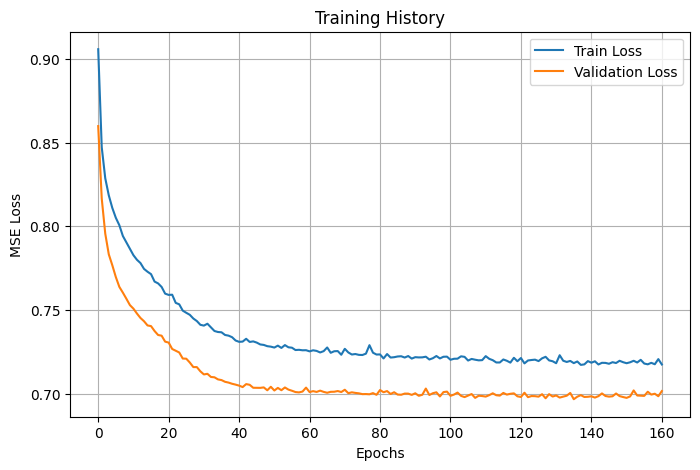

In [25]:
PlotHistory(history)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
R²_Training = 0.9537623632579959
MSE_Training = 0.0035513857063392907
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
R²_Validation = 0.9822441435474943
MSE_Validation = 0.0013219227751893922
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
R²_Test 1 = 0.5791268616857114
MSE_Test 1 = 0.033514746294346136


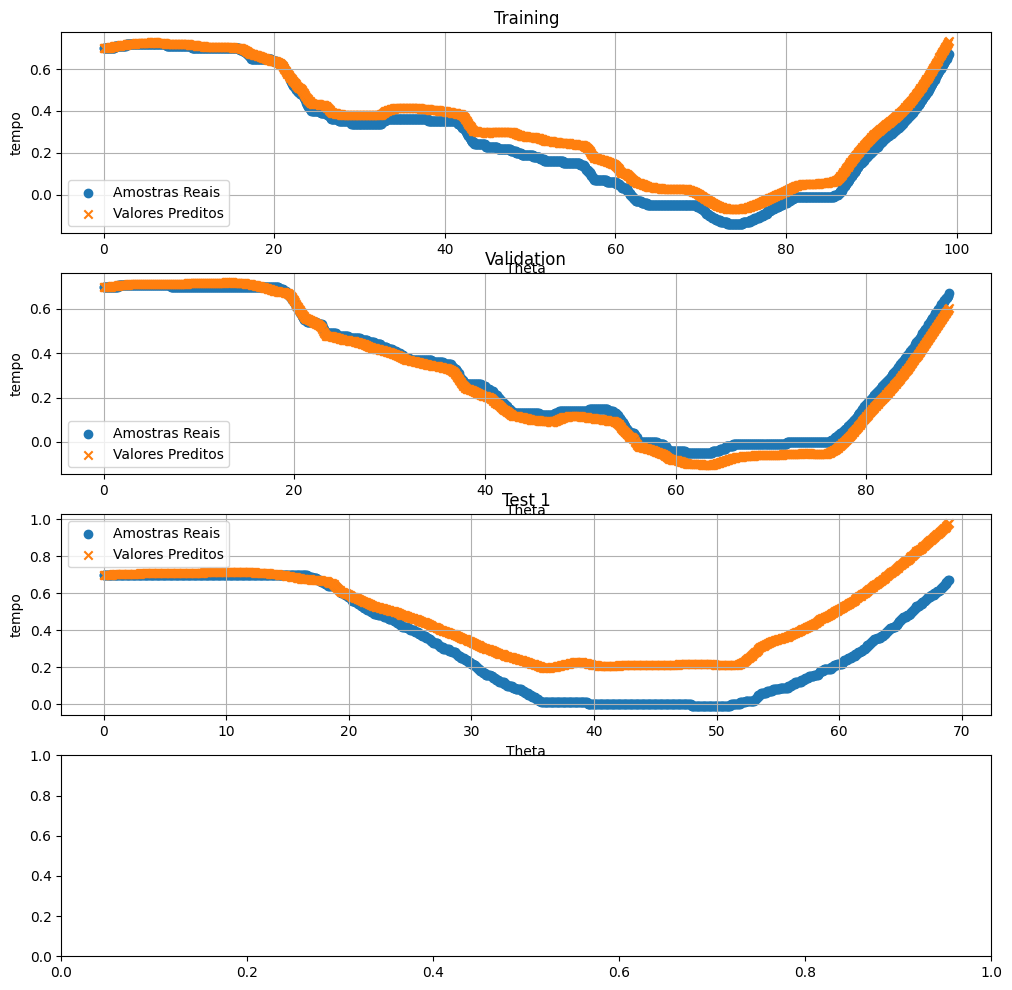

In [26]:
EvalModel(model)